<a href="https://colab.research.google.com/github/mathdavis26-tech/polygon-splitter/blob/main/Speed_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Results:

The find_half and find_half sympy versions run the same amount of time regardless over the number of vertices in the polygon. It depends only on the value of epsilon. The sympy version takes about twice as long to run as the normal verison.

The exact_half and exact_half sympy version iterate through all of the vertices of a polygon, so their runtime depends on how many vertices are in the polygon. That said, there is a huge difference between the sympy version and the normal version. The normal version is significantly faster. There does not seem to be a difference in accuracy between the normal and sympy version in most cases.

With Sympy

In [12]:
from sympy import *

In [57]:
import math

circle_sym = [(1,0), (sqrt(3)/2, -S(1)/2),(sqrt(2)/2, -sqrt(2)/2), (S(1)/2, -sqrt(3)/2),
          (0,-1), (-S(1)/2, -sqrt(3)/2), (-sqrt(2)/2, -sqrt(2)/2), (-sqrt(3)/2, -S(1)/2), (-1,0),
          (-sqrt(3)/2, S(1)/2), (-sqrt(2)/2, sqrt(2)/2), (-S(1)/2, sqrt(3)/2), (0,1), (S(1)/2, sqrt(3)/2),
          (sqrt(2)/2, sqrt(2)/2), (sqrt(3)/2, S(1)/2)] # Area ~= pi

non_convex = [(0,0), (2,1), (1,0), (4,-2), (0,-2)] # Area=5.5

import numpy as np
theta_list = [np.random.uniform(0, 2*math.pi) for _ in range(5000)]
theta_list.sort()
p_k = []
for theta in theta_list:
    p_k.append((math.cos(theta), math.sin(theta)))  # have p_k defined with 100 points


p_k2 = []
r= 2*math.cos(math.pi/10)
for theta in theta_list:
    if theta >= 0 and theta <(2/5) *math.pi:
        p_k2.append((r*(math.cos(theta/2+(2/10)*math.pi))+math.cos(13*math.pi/10),r*math.sin(theta/2+(2/10)*math.pi)+math.sin(13*math.pi/10)))
    elif theta >= (2/5)*math.pi and theta <(4/5)*math.pi:
        p_k2.append((r*(math.cos(theta/2 + (4/10)*math.pi))+math.cos(17*math.pi/10),r*math.sin(theta/2 + (4/10)*math.pi)+math.sin(17*math.pi/10)))
    elif theta >= (4/5)*math.pi and theta < (6/5)* math.pi:
        p_k2.append((r*(math.cos(theta/2 + (6/10)*math.pi))+math.cos(math.pi/10),r*math.sin(theta/2 + (6/10)*math.pi)+math.sin(math.pi/10)))
    elif theta >= (6/5)*math.pi and theta < (8/5) * math.pi:
        p_k2.append((r*(math.cos(theta/2 + (8/10)*math.pi))+math.cos(math.pi/2),r*math.sin(theta/2 + (8/10)*math.pi)+math.sin(math.pi/2)))
    elif theta >= (8/5)*math.pi and theta<2*math.pi:
        p_k2.append((r*(math.cos(theta/2 + math.pi))+math.cos(9*math.pi/10),r*math.sin(theta/2 + math.pi)+math.sin(9*math.pi/10)))

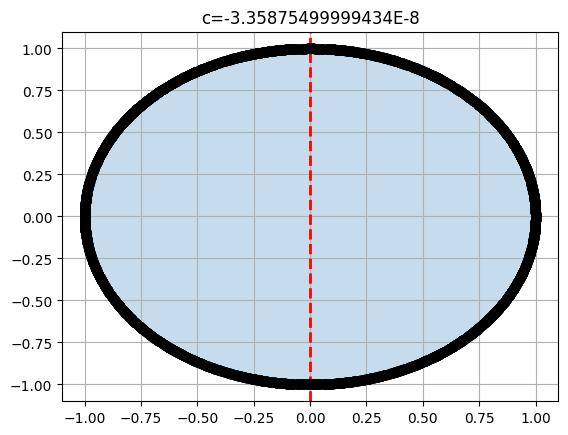

Execution time: 246.216889 seconds


In [58]:
import time
start_time = time.perf_counter()

ploting(p_k, (1,0), exact_half_sympy(p_k, (1,0))[1])
end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.6f} seconds")


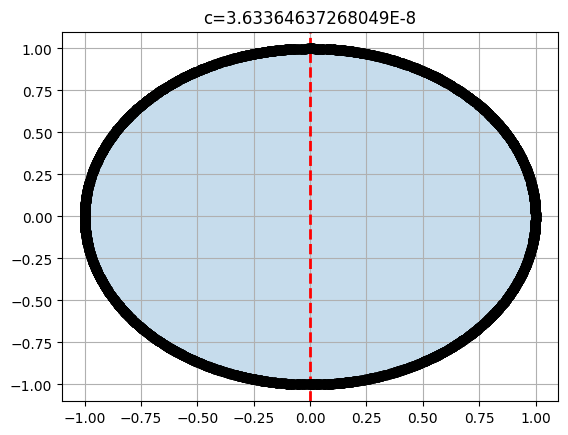

Execution time: 0.608985 seconds


In [59]:
start_time = time.perf_counter()

ploting(p_k, (1,0), find_half_sympy(p_k, (1,0), 10**(-5))[1])
end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.6f} seconds")

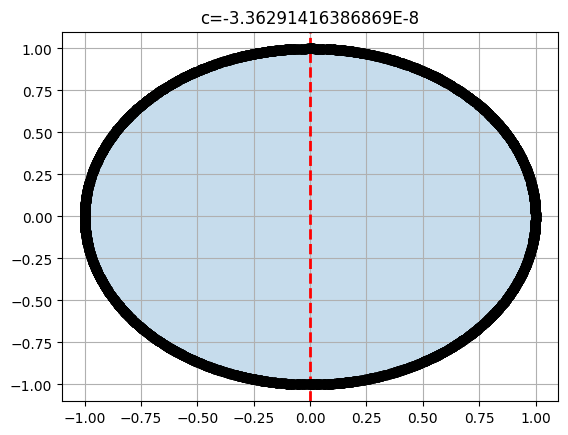

Execution time: 5.485668 seconds


In [60]:
start_time = time.perf_counter()

ploting(p_k, (1,0), find_half_sympy(p_k, (1,0), 10**(-10))[1])
end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.6f} seconds")

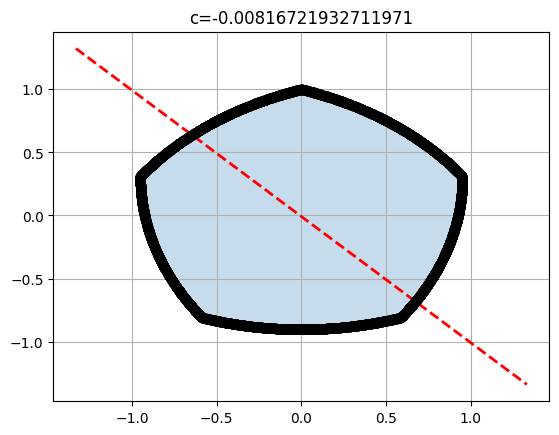

Execution time: 263.800765 seconds


In [61]:
start_time = time.perf_counter()

ploting(p_k2, (1,1), exact_half_sympy(p_k2, (1,1))[1])
end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.6f} seconds")

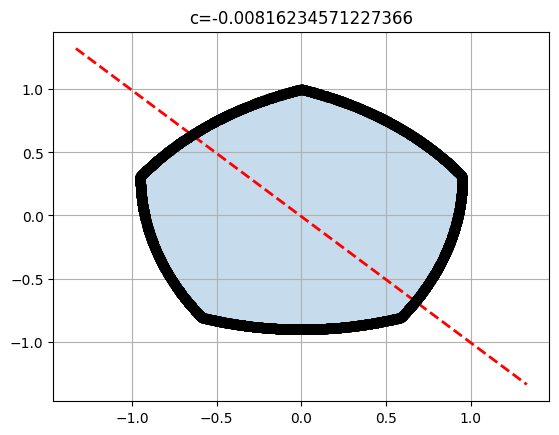

Execution time: 2.281869 seconds


In [62]:
start_time = time.perf_counter()

ploting(p_k2, (1,1), find_half_sympy(p_k2, (1,1), 10**(-5))[1])
end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.6f} seconds")

In [15]:
# finds half with accuracy epsilon
def find_half_sympy(shape, w, eps, max_iter=100):
    shape = [(S(x), S(y)) for x, y in shape]
    w = (S(w[0]), S(w[1]))
    A = area(shape)

    # Given a direction, the problem simplifies to finding a c that
    # cuts the polygon in half. This c must intersect the polygon, thus it must be between the
    # minimum and maximum c's that intersect the vertices
    c = []
    for xy in shape:
        c.append(w[0]*xy[0]+w[1]*xy[1])
    c_min = min(c)
    c_max=(max(c))
    # goal
    want = A/2
    # a good first guess is between the min and max
    c0 = (c_max + c_min)/2
    for _ in range(max_iter):
        # calculate the area below the line given a c0
        a, subshape = area_below_c(shape, w, c0)[0:2]

        if abs(a-want) < eps: # we are close enough to the true solution (within epsilon)
            return subshape, c0
        if a < want: # our area is too little, take a step towards the max
            c_min = c0
            c0 = (c0+c_max)/2
        if a > want: # our area is too large, take a step towards the min, note steps get smaller with each iteration
            c_max=c0
            c0 = (c_min +c0)/2



In [14]:
# The code below solves directly for the half without using an epsilon for error. It seperates the area
# into two regions. The first is the region going through a vertice with area close to but less than Area/2.
# The second region countains no vertices and the two regions together add up to Area/2. Because of this,
# in the second region, I can explicitly solve for the value of $c$ that solves Area($w^Tx \le c$) = Area/2 .

import numpy as np
# returns area below w^Tx = c, the vertices defining the subshape, and the value of c
# works on convex and non-convex polygons!!
def exact_half_sympy(shape, w):
    shape = [(S(x), S(y)) for x, y in shape]
    w = (S(w[0]), S(w[1]))
    A = area(shape)

    c = []
    for xy in shape:
        c.append(w[0]*xy[0]+w[1]*xy[1])
    c_sort = sorted(set(c), key=lambda z: float(N(z))) # find c values of vertices of polygon
    # above, "set" removes duplicates, "set" organizes according to the "key", which converts into float to compare numerically

    # initiate variables to store needed information
    c_range =[]
    want = A/2
    areas=[]

    # iterate over possible c values (in order)
    for i in range(len(c_sort)):
        a, subshape, key_points = area_below_c(shape, w, c_sort[i])
        areas.append(a)
        if a ==want:
            return subshape, c_sort[i] # if the line for half area goes through vertex
        if a > want: # since we start iterating from the negative end of c's, we find the c just above half area here
            c_range.append(c_sort[i-1])
            c_range.append(c_sort[i])
            a_below = areas[i-1]
            break

    c_mid = (c_range[0] + c_range[1])/2 # here, cutting NO vertices
    _, _, mid_keys = area_below_c(shape, w, c_mid)

    edges = sorted(edge for edge, point in mid_keys) # should already be sorted but this is ensures a sorting

    if len(edges)%2==0: # should always be the case because are not cutting any vertices
      x0, y0 = point_on_edge_at_c(shape, w, edges[0], c_range[0])
      u0, v0 = point_on_edge_at_c(shape, w, edges[1], c_range[0])

      x1, y1 = point_on_edge_at_c(shape, w, edges[0], c_range[1])
      u1, v1 = point_on_edge_at_c(shape, w, edges[1], c_range[1])


      c0 = c_range[0]
      # area function above defined to allow both clockwise and counterclockwise orderings of vertices (using absolute value)
      # the calculations below require the area to be signed depending on ordering of vertices
      # in the case that multiple parts are cut off the the main polygon, each subpart
      # should have the same ordering so I only need to check this once
      sub_area = (S(1)/2)*(x0*y1-y0*x1 + x1*v1 - y1*u1 + u1*v0 - v1*u0 + u0*y0 - v0*x0)
      if sub_area > 0:
          goal = want - a_below
      else:
          goal = -(want-a_below)
      change_c = c_range[1]-c_range[0]

      # defined points as (x,y)' = (x0, y0)' + t(x1-x0, y1-y0)', where t in [0,1]. To put in terms of c, t = (c-c0)/(c1-c0)
      # then found area using shoelace theorem, simplified to find constants of c^2, c, and 1

      # note that I am subtracting by the goal ONLY in c_const here
      c_const = ((-x0*c0*(y1-y0))/change_c -(x0*c0*(v1-v0))/change_c -(v0*c0*(x1-x0))/change_c
          +(c0**2*(x1-x0)*(v1-v0))/(change_c**2)-(v0*c0*(u1-u0))/change_c + (c0*y0*(x1-x0))/change_c
          + (y0*c0*(u1-u0))/change_c + (u0*c0*(y1-y0))/change_c - (c0**2*(y1-y0)*(u1-u0))/(change_c**2) +(u0*c0*(v1-v0))/change_c - 2*goal)

      b_const = ((x0*(y1-y0))/change_c + (x0*(v1-v0))/change_c + (v0*(x1-x0))/change_c - (2*c0*(x1-x0)*(v1-v0))/(change_c**2) + (v0*(u1-u0))/change_c
          - (y0*(x1-x0))/change_c - (y0*(u1-u0))/change_c - (u0*(y1-y0))/change_c + (2*c0*(y1-y0)*(u1-u0))/(change_c**2) - (u0*(v1-v0))/change_c)

      a_const = ((x1-x0)*(v1-v0))/(change_c**2) - ((y1-y0)*(u1-u0))/(change_c**2)

      # same as above but for any other cut off parts, if any
      for i in range(int(len(edges)/2)-1):
        x0, y0 = point_on_edge_at_c(shape, w, edges[2*i+2], c_range[0])
        u0, v0 = point_on_edge_at_c(shape, w, edges[2*i+3], c_range[0])

        x1, y1 = point_on_edge_at_c(shape, w, edges[2*i+2], c_range[1])
        u1, v1 = point_on_edge_at_c(shape, w, edges[2*i+3], c_range[1])

        # note I do NOT subtract by goal here agin
        c_const += ((-x0*c0*(y1-y0))/change_c -(x0*c0*(v1-v0))/change_c -(v0*c0*(x1-x0))/change_c
            +(c0**2*(x1-x0)*(v1-v0))/(change_c**2)-(v0*c0*(u1-u0))/change_c + (c0*y0*(x1-x0))/change_c
            + (y0*c0*(u1-u0))/change_c + (u0*c0*(y1-y0))/change_c - (c0**2*(y1-y0)*(u1-u0))/(change_c**2) +(u0*c0*(v1-v0))/change_c)

        b_const += ((x0*(y1-y0))/change_c + (x0*(v1-v0))/change_c + (v0*(x1-x0))/change_c - (2*c0*(x1-x0)*(v1-v0))/(change_c**2) + (v0*(u1-u0))/change_c
            - (y0*(x1-x0))/change_c - (y0*(u1-u0))/change_c - (u0*(y1-y0))/change_c + (2*c0*(y1-y0)*(u1-u0))/(change_c**2) - (u0*(v1-v0))/change_c)

        a_const += ((x1-x0)*(v1-v0))/(change_c**2) - ((y1-y0)*(u1-u0))/(change_c**2)

      a_const = simplify(a_const)
      b_const = simplify(b_const)
      c_const = simplify(c_const)

      # apply quadratic formula
      if a_const != 0:
        if c_const == 0: # zero is a root, using quadratic formula directly -> errors
          roots = [S(0), simplify(-b_const/a_const)]
          # compare roots using float to see if in range
          valid_roots = [root for root in roots if float(N(c_range[0])) < float(N(root))< float(N(c_range[1]))]
          if len(valid_roots)!=1:
            raise ValueError('Problem with root when c=0')
          c1 = valid_roots[0]
          return area_below_c(shape, w, c1)[1], c1

        else:
          c1 = (-b_const + sqrt(b_const**2-4*a_const*c_const))/(2*a_const)
          c2 = (-b_const - sqrt(b_const**2-4*a_const*c_const))/(2*a_const)
          c1 = simplify(c1)
          c2 = simplify(c2)

          # when only one solution
          if c1==c2:
              return area_below_c(shape,w, c1)[1],c1

          # make comparison using floats
          true1 = float(N(c_range[0])) < float(N(c1))<float(N(c_range[1]))
          true2 = float(N(c_range[0])) < float(N(c2)) < float(N(c_range[1]))

          if true1 and true2:
              raise ValueError('Somethings very wrong') # there should only be one c that satisfies the area constraint
          elif true1:
              return area_below_c(shape, w, c1)[1], c1
          elif true2:
              return area_below_c(shape, w, c2)[1], c2
          else:
              raise ValueError('I give up')
      else:
          c1 = -c_const/b_const # solve the linear function when a_const=0
          return area_below_c(shape, w, c1)[1], c1
    else:
      raise ValueError('Number of Edges not even')

Without Sympy

In [18]:
import math

circle = [(1,0), (math.sqrt(3)/2, -1/2),(math.sqrt(2)/2, -math.sqrt(2)/2), (1/2, -math.sqrt(3)/2),
          (0,-1), (-1/2, -math.sqrt(3)/2), (-math.sqrt(2)/2, -math.sqrt(2)/2), (-math.sqrt(3)/2, -1/2), (-1,0),
          (-math.sqrt(3)/2, 1/2), (-math.sqrt(2)/2, math.sqrt(2)/2), (-1/2, math.sqrt(3)/2), (0,1), (1/2, math.sqrt(3)/2),
          (math.sqrt(2)/2, math.sqrt(2)/2), (math.sqrt(3)/2, 1/2)] # Area ~= pi

non_convex = [(0,0), (2,1), (1,0), (4,-2), (0,-2)] # Area=5.5

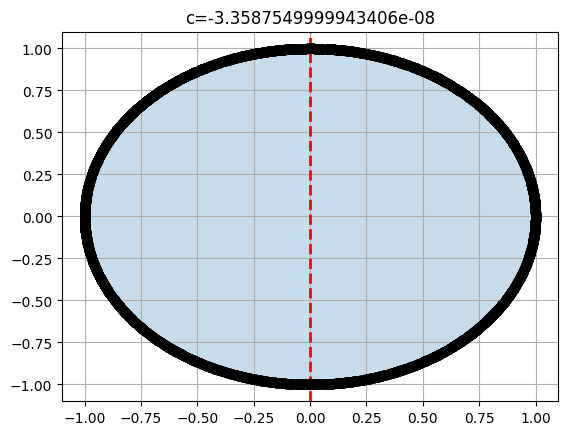

Execution time: 9.033226 seconds


In [63]:
import time

start_time = time.perf_counter()

ploting(p_k, (1,0), exact_half(p_k, (1,0))[1])

end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.6f} seconds")

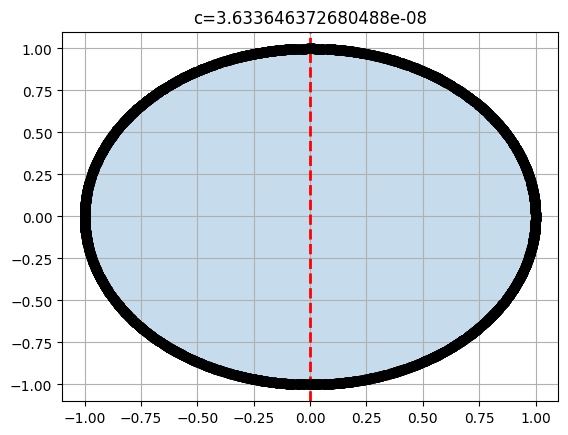

Execution time: 0.314940 seconds


In [64]:
start_time = time.perf_counter()

ploting(p_k, (1,0), find_half(p_k, (1,0), 10**(-5))[1])
end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.6f} seconds")

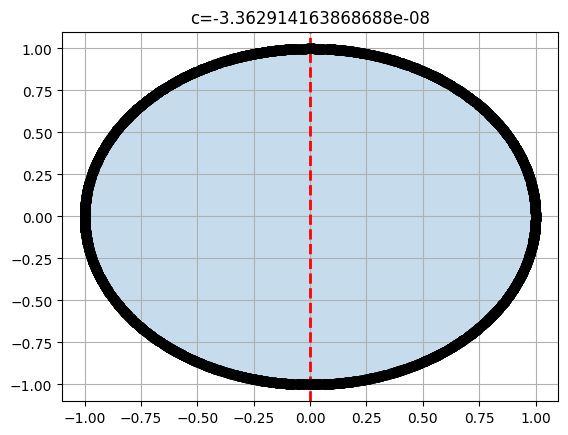

Execution time: 0.398887 seconds


In [65]:
start_time = time.perf_counter()

ploting(p_k, (1,0), find_half(p_k, (1,0), 10**(-10))[1])
end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.6f} seconds")

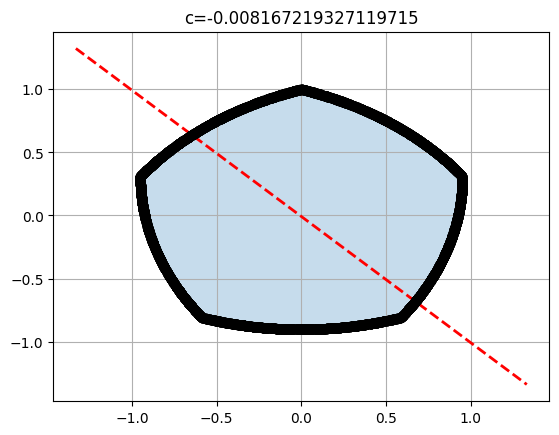

Execution time: 8.596971 seconds


In [66]:
start_time = time.perf_counter()

ploting(p_k2, (1,1), exact_half(p_k2, (1,1))[1])
end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.6f} seconds")

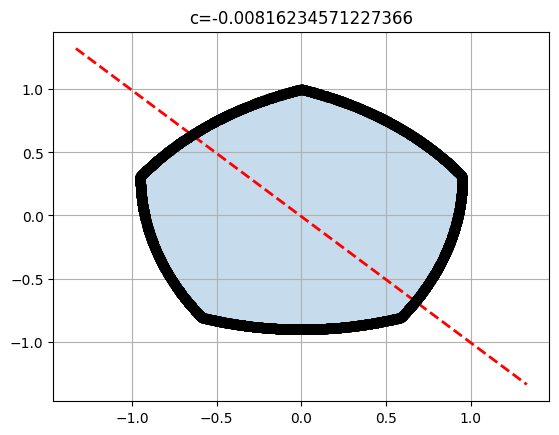

Execution time: 0.306468 seconds


In [67]:
start_time = time.perf_counter()

ploting(p_k2, (1,1), find_half(p_k2, (1,1), 10**(-5))[1])
end_time = time.perf_counter()
print(f"Execution time: {end_time - start_time:.6f} seconds")

In [9]:
def area(shape):
    total=0

    n = len(shape)
    for i in range(n):
        x1, y1 = shape[i]
        x2,y2 = shape[(i+1)%n] # modulo means that entry n+1 = entry 1

        total += x1*y2-y1*x2
    return abs(total)/2

import numpy as np
def area_below_c(shape, w, c):
    # truth values to determine information about previous values
    flag = False # true when the first vertex is <= c
    prev = True # true when the previous vertex is <=c
    on_boundary=True # true when the previous vertex is ==c. Starts out as true for the case that the first vertex seen is >c
    first_bound = False # true when the first item is on the boundary
    # store the vertices defining the area below the line
    subshape = []
    key_points=[]
    # iterate over vertices of the shape
    for i in range(len(shape)):
        boundary = w[0]*shape[i][0]+w[1]*shape[i][1] # w^Tx
        edge = (i-1)%len(shape)

        # if below the line
        if boundary < c:
            # if the previous vertex seen was not below the line, the line intersected between the two vertices. Add this point to the shape
            if not prev:
                c0 = w[0]*shape[i-1][0]+w[1]*shape[i-1][1]
                change_c = w[0]*(shape[i][0]-shape[i-1][0])+w[1]*(shape[i][1]-shape[i-1][1])
                x = shape[i-1][0]+((c-c0)/change_c)*(shape[i][0]-shape[i-1][0])
                y = shape[i-1][1]+((c-c0)/change_c)*(shape[i][1]-shape[i-1][1])
                subshape.append((x,y))
                key_points.append((edge,(x,y)))
            # add the current vertex/corner to shape
            subshape.append(shape[i])
            # adjust truth values
            prev = True
            on_boundary=False
            if i == 0:
                flag = True
            # look for an intersection between vertices if the first vertex was not under and the last one is
            if i == len(shape)-1 and not flag:
                c0 = boundary
                change_c = w[0]*(shape[0][0]-shape[i][0])+w[1]*(shape[0][1]-shape[i][1])
                x = shape[i][0]+((c-c0)/change_c)*(shape[0][0]-shape[i][0])
                y = shape[i][1]+((c-c0)/change_c)*(shape[0][1]-shape[i][1])
                subshape.append((x,y))
                key_points.append((i,(x,y)))

        # exact intersection is simply adding vertex to shape
        if boundary == c:
            subshape.append(shape[i])
            key_points.append((edge,shape[i]))
            on_boundary = True
            prev=True
            if i == 0:
                flag = True
                first_bound = True

        # if above the line
        if boundary > c:
            # the previous vertex was under the line and was not on the line, must've intersected between lines
            if prev and not on_boundary:
                c0 = w[0]*shape[i-1][0]+w[1]*shape[i-1][1]
                change_c = w[0]*(shape[i][0]-shape[i-1][0])+w[1]*(shape[i][1]-shape[i-1][1])
                x = shape[i-1][0]+((c-c0)/change_c)*(shape[i][0]-shape[i-1][0])
                y = shape[i-1][1]+((c-c0)/change_c)*(shape[i][1]-shape[i-1][1])
                subshape.append((x,y))
                key_points.append((edge,(x,y)))
            # Adjust truth values
            prev = False
            if i== 0:
                flag = False
            on_boundary = False
            # the first vertex was below and the last is above, must intersect between them
            if i == len(shape)-1 and flag and not first_bound:
                c0 = boundary
                change_c = w[0]*(shape[0][0]-shape[i][0])+w[1]*(shape[0][1]-shape[i][1])
                x = shape[i][0]+((c-c0)/change_c)*(shape[0][0]-shape[i][0])
                y = shape[i][1]+((c-c0)/change_c)*(shape[0][1]-shape[i][1])
                subshape.append((x,y))
                key_points.append((i,(x,y)))

    return area(subshape), subshape, key_points

def find_half(shape, w, eps, max_iter=100):
    A = area(shape)
    # Given a direction, the problem simplifies to finding a c that
    # cuts the polygon in half. This c must intersect the polygon, thus it must be between the
    # minimum and maximum c's that intersect the vertices
    c = []
    for xy in shape:
        c.append(w[0]*xy[0]+w[1]*xy[1])
    c_min = min(c)
    c_max=(max(c))
    # goal
    want = A/2
    # a good first guess is between the min and max
    c0 = (c_max + c_min)/2
    for _ in range(max_iter):
        # calculate the area below the line given a c0
        a, subshape = area_below_c(shape, w, c0)[0:2]

        if abs(a-want) < eps: # we are close enough to the true solution (within epsilon)
            return subshape, c0
        if a < want: # our area is too little, take a step towards the max
            c_min = c0
            c0 = (c0+c_max)/2
        if a > want: # our area is too large, take a step towards the min, note steps get smaller with each iteration
            c_max=c0
            c0 = (c_min +c0)/2

def point_on_edge_at_c(shape, w, edge, c):
    n = len(shape)
    p0 = shape[edge] # the edge is one end(vertex) of the line
    p1 = shape[(edge+1)%n] # other defining vertex

    c0 = w[0]*p0[0] +w[1]*p0[1]
    c1 = w[0]*p1[0] +w[1]*p1[1]
    t = (c-c0)/(c1-c0)

    # calculate intersection point
    x = p0[0] + t*(p1[0]-p0[0])
    y = p0[1] + t*(p1[1]-p0[1])

    return x,y


import math
# returns area below w^Tx = c, the vertices defining the subshape, and the value of c
# works on convex and non-convex polygons!!
def exact_half(shape, w):
    A = area(shape)

    c = []
    for xy in shape:
        c.append(w[0]*xy[0]+w[1]*xy[1])
    c = np.array(c)
    c_sort = np.unique(c) # find c values of vertices of polygon

    # initiate variables to store needed information
    c_range =[]
    want = A/2
    areas=[]

    # iterate over possible c values (in order)
    for i in range(len(c_sort)):
        a, subshape, key_points = area_below_c(shape, w, c_sort[i])
        areas.append(a)
        if a ==want:
            return subshape, c_sort[i] # if the line for half area goes through vertex
        if a > want: # since we start iterating from the negative end of c's, we find the c just above half area here
            c_range.append(c_sort[i-1])
            c_range.append(c_sort[i])
            a_below = areas[i-1]
            break

    c_mid = (c_range[0] + c_range[1])/2 # here, cutting NO vertices
    _, _, mid_keys = area_below_c(shape, w, c_mid)

    edges = sorted(edge for edge, point in mid_keys) # should already be sorted but this is ensures a sorting

    if len(edges)%2==0: # should always be the case because are not cutting any vertices
      x0, y0 = point_on_edge_at_c(shape, w, edges[0], c_range[0])
      u0, v0 = point_on_edge_at_c(shape, w, edges[1], c_range[0])

      x1, y1 = point_on_edge_at_c(shape, w, edges[0], c_range[1])
      u1, v1 = point_on_edge_at_c(shape, w, edges[1], c_range[1])


      c0 = c_range[0]
      # area function above defined to allow both clockwise and counterclockwise orderings of vertices (using absolute value)
      # the calculations below require the area to be signed depending on ordering of vertices
      # in the case that multiple parts are cut off the the main polygon, each subpart
      # should have the same ordering so I only need to check this once
      sub_area = 1/2*(x0*y1-y0*x1 + x1*v1 - y1*u1 + u1*v0 - v1*u0 + u0*y0 - v0*x0)
      if sub_area > 0:
          goal = want - a_below
      else:
          goal = -(want-a_below)
      change_c = c_range[1]-c_range[0]

      # defined points as (x,y)' = (x0, y0)' + t(x1-x0, y1-y0)', where t in [0,1]. To put in terms of c, t = (c-c0)/(c1-c0)
      # then found area using shoelace theorem, simplified to find constants of c^2, c, and 1

      # note that I am subtracting by the goal ONLY in c_const here
      c_const = ((-x0*c0*(y1-y0))/change_c -(x0*c0*(v1-v0))/change_c -(v0*c0*(x1-x0))/change_c
          +(c0**2*(x1-x0)*(v1-v0))/(change_c**2)-(v0*c0*(u1-u0))/change_c + (c0*y0*(x1-x0))/change_c
          + (y0*c0*(u1-u0))/change_c + (u0*c0*(y1-y0))/change_c - (c0**2*(y1-y0)*(u1-u0))/(change_c**2) +(u0*c0*(v1-v0))/change_c - 2*goal)

      b_const = ((x0*(y1-y0))/change_c + (x0*(v1-v0))/change_c + (v0*(x1-x0))/change_c - (2*c0*(x1-x0)*(v1-v0))/(change_c**2) + (v0*(u1-u0))/change_c
          - (y0*(x1-x0))/change_c - (y0*(u1-u0))/change_c - (u0*(y1-y0))/change_c + (2*c0*(y1-y0)*(u1-u0))/(change_c**2) - (u0*(v1-v0))/change_c)

      a_const = ((x1-x0)*(v1-v0))/(change_c**2) - ((y1-y0)*(u1-u0))/(change_c**2)

      # same as above but for any other cut off parts, if any
      for i in range(int(len(edges)/2)-1):
        x0, y0 = point_on_edge_at_c(shape, w, edges[2*i+2], c_range[0])
        u0, v0 = point_on_edge_at_c(shape, w, edges[2*i+3], c_range[0])

        x1, y1 = point_on_edge_at_c(shape, w, edges[2*i+2], c_range[1])
        u1, v1 = point_on_edge_at_c(shape, w, edges[2*i+3], c_range[1])

        # note I do NOT subtract by goal here agin
        c_const += ((-x0*c0*(y1-y0))/change_c -(x0*c0*(v1-v0))/change_c -(v0*c0*(x1-x0))/change_c
            +(c0**2*(x1-x0)*(v1-v0))/(change_c**2)-(v0*c0*(u1-u0))/change_c + (c0*y0*(x1-x0))/change_c
            + (y0*c0*(u1-u0))/change_c + (u0*c0*(y1-y0))/change_c - (c0**2*(y1-y0)*(u1-u0))/(change_c**2) +(u0*c0*(v1-v0))/change_c)

        b_const += ((x0*(y1-y0))/change_c + (x0*(v1-v0))/change_c + (v0*(x1-x0))/change_c - (2*c0*(x1-x0)*(v1-v0))/(change_c**2) + (v0*(u1-u0))/change_c
            - (y0*(x1-x0))/change_c - (y0*(u1-u0))/change_c - (u0*(y1-y0))/change_c + (2*c0*(y1-y0)*(u1-u0))/(change_c**2) - (u0*(v1-v0))/change_c)

        a_const += ((x1-x0)*(v1-v0))/(change_c**2) - ((y1-y0)*(u1-u0))/(change_c**2)


      # apply quadratic formula
      if a_const != 0:
          if c_const == 0:
              roots = [0, -b_const/a_const]
              valid_roots = [root for root in roots if c_range[0]<root <c_range[1]]
              if len(roots)!=1:
                  raise ValueError("Too many roots when c=0")
              c1 = valid_roots[0]
              return area_below_c(shape, w, c1)[1], c1
          else:
              c1 = (-b_const + math.sqrt(b_const**2-4*a_const*c_const))/(2*a_const)
              c2 = (-b_const - math.sqrt(b_const**2-4*a_const*c_const))/(2*a_const)

              # when only one solution
              if c1==c2:
                  return area_below_c(shape,w, c1)[1],c1

              true1 = c1 > c_range[0] and c1 < c_range[1]
              true2 = c2 > c_range[0] and c2 < c_range[1]

              if true1 and true2:
                  raise ValueError('Somethings very wrong') # there should only be one c that satisfies the area constraint
              elif true1:
                  return area_below_c(shape, w, c1)[1], c1
              elif true2:
                  return area_below_c(shape, w, c2)[1], c2
              else:
                  raise ValueError('I give up')
      else:
          c1 = -c_const/b_const # solve the linear function when a_const=0
          return area_below_c(shape, w, c1)[1], c1
    else:
      raise ValueError('Number of Edges not even')


import matplotlib.pyplot as plt
# plotting code generated by AI
def ploting(shape, w, c):

    shape = np.array(shape, dtype=float)
    w = np.array(w, dtype=float)
    closed = np.vstack([shape, shape[0]])

    fig, ax = plt.subplots()

    # Plot polygon
    ax.plot(closed[:,0], closed[:,1], "k-", linewidth=2)
    ax.fill(shape[:,0], shape[:,1], alpha=0.25)
    ax.scatter(shape[:,0], shape[:,1], color="black", zorder=3)
    plt.title('c={}'.format(c))

    # plot bounds
    xmin, xmax = shape[:,0].min(), shape[:,0].max()
    ymin, ymax = shape[:,1].min(), shape[:,1].max()
    xpad = 0.2* (xmax-xmin if xmax > xmin else 1)
    ypad = 0.2*(ymax-ymin if ymax>ymin else 1)
    xmin -=xpad; xmax +=xpad; ymin -=ypad; ymax+=ypad

    w1, w2=w

    if abs(w2) > 1e-12:
        xs = np.linspace(xmin, xmax, 400)
        ys = (c-w1*xs)/w2
        ax.plot(xs, ys, "r--", linewidth=2)
    elif abs(w1) > 1e-12:
        x = c/w1
        ax.axvline(x, color='red', linestyle='--', linewidth=2)
    else:
        raise ValueError('w is zero vector')
    ax.grid(True)
    plt.show()


